# **Klasifikasi Bahasa Isyarat | K - Nearest Neighbours**

Klasifikasi bahasa isyarat menggunakan algoritma K - Nearest Neighbours.

## 1. Data Understanding 

### 1.1 Import Library 

In [677]:
# Impor pustaka yang diperlukan 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 Import & Dataset Understanding 

In [678]:
# Import data train & test 
sibi_train = pd.read_csv('Datafull train.csv')
sibi_test = pd.read_csv('datatest.csv')

In [679]:
# Tmpilkan 5 baris teratas data train
print('\n5 baris teratas data train:')
sibi_train.head()


5 baris teratas data train:


,0x;0y;1x;1y;2x;2y;3x;3y;4x;4y;5x;5y;6x;6y;7x;7y;8x;8y;9x;9y;10x;10y;11x;11y;12x;12y;13x;13y;14x;14y;15x;15y;16x;16y;17x;17y;18x;18y;19x;19y;20x;20y;char
0,449.894;638.530;329.537;588.029;262.366;475.70...
1,459.426;638.641;347.614;599.550;273.522;486.96...
2,444.194;659.268;326.598;616.910;253.226;497.91...
3,443.780;650.429;324.970;607.825;252.818;487.20...
4,452.860;638.769;340.436;595.407;272.323;487.49...


In [680]:
# Pisah kolom data train 
sibi_train = pd.read_csv('Datafull train.csv', sep=';')
sibi_train.head()


,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16y,17x,17y,18x,18y,19x,19y,20x,20y,char
0,449.894,638.530,329.537,588.029,262.366,475.709,253.967,343.421,247.663,236.477,...,475.346,591.398,426.475,592.339,341.419,548.671,413.658,541.039,454.239,NaN
1,459.426,638.641,347.614,599.550,273.522,486.969,262.374,354.810,248.102,248.011,...,471.021,587.605,425.540,598.047,337.165,559.660,410.858,548.164,455.238,A
2,444.194,659.268,326.598,616.910,253.226,497.914,243.082,361.876,239.491,259.676,...,476.613,560.803,418.030,567.584,346.090,533.656,416.844,524.283,450.811,A
3,443.780,650.429,324.970,607.825,252.818,487.201,244.345,356.561,243.655,256.638,...,473.187,573.173,418.568,580.205,339.026,541.187,411.295,528.062,445.777,A
4,452.860,638.769,340.436,595.407,272.323,487.497,254.365,357.569,231.482,241.993,...,463.566,577.341,425.073,581.486,337.553,551.375,410.228,546.574,449.936,A


In [681]:
# Tampilkan 5 baris teratas data test
print('\n5 baris teratas data test:')
sibi_test.head()


5 baris teratas data test:


,0x;0y;1x;1y;2x;2y;3x;3y;4x;4y;5x;5y;6x;6y;7x;7y;8x;8y;9x;9y;10x;10y;11x;11y;12x;12y;13x;13y;14x;14y;15x;15y;16x;16y;17x;17y;18x;18y;19x;19y;20x;20y;char
0,449.429;643.857;327.271;587.170;265.731;484.23...
1,451.351;653.700;333.252;594.944;265.111;486.31...
2,457.565;692.363;335.312;635.283;267.992;518.50...
3,454.034;534.794;333.222;489.421;258.394;399.01...
4,449.840;545.633;327.645;504.473;256.748;405.65...


In [682]:
# Pisah kolom data train 
sibi_test = pd.read_csv('datatest.csv', sep=';')
sibi_test.head()

,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16y,17x,17y,18x,18y,19x,19y,20x,20y,char
0,449.429,643.857,327.271,587.170,265.731,484.233,246.689,362.602,231.657,252.290,...,480.806,582.295,427.375,587.343,339.388,547.296,415.208,536.242,454.387,NaN
1,451.351,653.700,333.252,594.944,265.111,486.310,256.936,354.813,248.984,239.251,...,491.502,598.279,438.230,609.486,345.403,559.002,414.437,543.311,457.700,A
2,457.565,692.363,335.312,635.283,267.992,518.501,261.948,388.552,264.993,288.713,...,490.838,584.324,453.037,589.529,370.452,548.982,435.461,536.997,465.605,A
3,454.034,534.794,333.222,489.421,258.394,399.013,232.771,269.755,218.668,160.658,...,358.808,537.166,308.455,531.600,212.394,505.065,284.374,499.484,329.256,A
4,449.840,545.633,327.645,504.473,256.748,405.653,228.244,273.756,210.097,166.311,...,365.462,545.115,312.461,548.587,221.122,514.636,287.484,503.828,326.010,A


In [683]:
# Tampilkan informasi data train
print('\nInformasi data train:')
sibi_train.info()


Informasi data train:
<class 'pandas.DataFrame'>
RangeIndex: 32849 entries, 0 to 32848
Data columns (total 43 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0x      32849 non-null  float64
 1   0y      32849 non-null  float64
 2   1x      32849 non-null  float64
 3   1y      32849 non-null  float64
 4   2x      32849 non-null  float64
 5   2y      32849 non-null  float64
 6   3x      32849 non-null  float64
 7   3y      32849 non-null  float64
 8   4x      32849 non-null  float64
 9   4y      32849 non-null  float64
 10  5x      32849 non-null  float64
 11  5y      32849 non-null  float64
 12  6x      32849 non-null  float64
 13  6y      32849 non-null  float64
 14  7x      32849 non-null  float64
 15  7y      32849 non-null  float64
 16  8x      32849 non-null  float64
 17  8y      32849 non-null  float64
 18  9x      32849 non-null  float64
 19  9y      32849 non-null  float64
 20  10x     32849 non-null  float64
 21  10y     32849 non-null 

In [684]:
# Tampilkan informasi data test
print('\nInformasi data test')
sibi_test.info()


Informasi data test
<class 'pandas.DataFrame'>
RangeIndex: 8213 entries, 0 to 8212
Data columns (total 43 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0x      8213 non-null   float64
 1   0y      8213 non-null   float64
 2   1x      8213 non-null   float64
 3   1y      8213 non-null   float64
 4   2x      8213 non-null   float64
 5   2y      8213 non-null   float64
 6   3x      8213 non-null   float64
 7   3y      8213 non-null   float64
 8   4x      8213 non-null   float64
 9   4y      8213 non-null   float64
 10  5x      8213 non-null   float64
 11  5y      8213 non-null   float64
 12  6x      8213 non-null   float64
 13  6y      8213 non-null   float64
 14  7x      8213 non-null   float64
 15  7y      8213 non-null   float64
 16  8x      8213 non-null   float64
 17  8y      8213 non-null   float64
 18  9x      8213 non-null   float64
 19  9y      8213 non-null   float64
 20  10x     8213 non-null   float64
 21  10y     8213 non-null   flo

In [685]:
# Tampilkan dimensi dataset
print('\nDimensi data train:')
print('Jumlah baris:', sibi_train.shape[0])
print('Jumlah kolom:', sibi_train.shape[1])

print('\nDimensi data test:')
print('Jumlah baris:', sibi_test.shape[0])
print('Jumlah kolom:', sibi_test.shape[1])


Dimensi data train:
Jumlah baris: 32849
Jumlah kolom: 43

Dimensi data test:
Jumlah baris: 8213
Jumlah kolom: 43


In [686]:
# Ambil sample 10% dari total data train 
# sibi = sibi_train.groupby('char', group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42)).reset_index(drop=True)
sibi = sibi_train.groupby('char').sample(frac=0.1, random_state=42).reset_index(drop=True)

print('\nDimensi data train setelah diambil sampel:')
print('Jumlah baris:', sibi.shape[0])
print('Jumlah kolom:', sibi.shape[1])


Dimensi data train setelah diambil sampel:
Jumlah baris: 3283
Jumlah kolom: 43


In [687]:
sibi.head()

,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16y,17x,17y,18x,18y,19x,19y,20x,20y,char
0,464.530,453.149,410.669,380.667,403.724,283.813,432.110,189.088,451.753,106.248,...,354.814,600.751,361.646,641.236,309.935,601.943,337.724,583.792,361.384,A
1,437.530,466.701,372.401,425.682,333.999,373.071,322.827,312.913,322.848,261.393,...,380.057,514.758,360.718,512.502,306.447,489.769,343.545,489.146,366.170,A
2,440.916,455.722,407.954,381.635,420.406,305.575,446.657,241.038,456.185,183.758,...,387.420,560.011,400.332,587.656,367.523,547.735,375.884,521.679,387.713,A
3,456.665,471.524,393.749,430.490,370.009,370.682,362.451,303.936,360.115,252.860,...,391.638,522.869,369.780,524.829,331.082,508.788,365.535,508.151,384.290,A
4,470.986,470.530,386.005,437.175,333.821,369.394,307.130,298.090,278.775,252.963,...,286.195,507.711,328.714,519.402,260.946,502.775,266.959,489.401,283.085,A


In [688]:
# Tampilkan total nilai unik data train
print('\nTotal nilai unik per fitur:')
sibi.nunique()


Total nilai unik per fitur:


0x      3209
0y      3241
1x      3255
1y      3253
2x      3266
2y      3258
3x      3270
3y      3268
4x      3273
4y      3265
5x      3265
5y      3247
6x      3265
6y      3257
7x      3269
7y      3265
8x      3269
8y      3273
9x      3252
9y      3247
10x     3259
10y     3262
11x     3270
11y     3271
12x     3264
12y     3262
13x     3256
13y     3256
14x     3265
14y     3258
15x     3273
15y     3259
16x     3263
16y     3267
17x     3255
17y     3252
18x     3262
18y     3262
19x     3256
19y     3271
20x     3250
20y     3265
char      24
dtype: int64

In [689]:
# Tampilkan total missing value
print('\nTotal missing value:', sibi.isnull().sum().sum())


Total missing value: 2


In [690]:
# Tampilkan baris dengan missing value
print('\nBaris dengan missing value:')
sibi[sibi.isnull().any(axis=1)]


Baris dengan missing value:


,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16y,17x,17y,18x,18y,19x,19y,20x,20y,char
2930,466.676,511.330,437.468,476.821,425.520,426.249,445.661,368.384,471.18,323.275,...,177.521,512.341,372.334,524.862,319.886,533.224,312.037,544.295,312.006,W
3262,475.041,461.168,428.015,420.309,414.385,356.866,411.954,294.457,405.98,236.464,...,375.186,NaN,376.812,627.962,321.987,653.961,288.299,678.118,267.209,Y


In [691]:
# Tampilkan total data duplikat 
print('\nTotal data duplikat:', sibi.duplicated().sum())


Total data duplikat: 0


In [692]:
# Tampilkan baris duplikat 
print('\nBaris duplikat:')
sibi[sibi.duplicated(keep=False)]


Baris duplikat:


,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16y,17x,17y,18x,18y,19x,19y,20x,20y,char


In [693]:
# Pisah fitur numerik dan kategorikal
num_cols = sibi_train.select_dtypes(include=['int64', 'float64'])
cat_cols = sibi_train.select_dtypes(include=['category', 'object'])

/tmp/ipykernel_57876/4003604695.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = sibi_train.select_dtypes(include=['category', 'object'])


## 2. Exploratory Data Analysis (EDA)

### 2.1 Multivariate Analysis

In [694]:
# Tampilkan statistik dataset
print('\nStatistik fitur numerik:')
sibi_train.describe()


Statistik fitur numerik:


,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16x,16y,17x,17y,18x,18y,19x,19y,20x,20y
count,32849.000000,32849.000000,32849.000000,32849.000000,32849.00000,32849.000000,32849.000000,32849.000000,32849.000000,32849.000000,...,32847.000000,32846.000000,32844.000000,32848.000000,32849.000000,32848.000000,32849.000000,32849.000000,32849.000000,32849.000000
mean,452.487562,475.714510,427.711225,445.098657,423.43866,400.280874,438.871542,362.268773,452.668220,338.853849,...,498.978343,364.348394,521.897306,387.946387,535.892408,354.024572,525.676819,358.802615,517.353640,365.814100
std,33.520120,52.909844,54.618299,52.776351,80.52885,69.214755,101.527047,93.655925,120.968362,114.740541,...,102.025223,118.615725,66.132425,73.711071,87.463863,96.457858,93.328696,103.021041,97.024746,110.399991
min,26.970000,0.000000,0.000000,0.000000,-30.64200,0.000000,-67.560000,0.000000,-95.991000,0.000000,...,-139.906000,7.845000,-49.063000,54.555000,-83.522000,35.426000,-92.401000,39.292000,-98.609000,45.460000
25%,441.028000,453.376000,391.581000,410.966000,365.05200,352.689000,367.965000,300.572000,374.013000,264.204000,...,452.645000,304.218000,493.478000,340.677750,494.840000,290.776000,483.768000,291.999000,475.193000,296.790000
50%,450.211000,468.697000,413.540000,436.465000,407.72500,383.968000,430.541000,337.837000,452.060000,310.332000,...,489.608000,365.309500,529.412000,371.636500,545.175000,329.886000,531.410000,341.738000,517.521000,359.703000
75%,461.090000,491.656000,463.077000,471.833000,479.73100,433.306000,506.223000,396.942000,530.462000,375.741000,...,543.359000,409.731500,559.936250,423.889000,589.752000,392.063000,577.235000,400.458000,567.809000,414.288000
max,846.956000,964.173000,822.414000,861.044000,835.39700,828.416000,854.552000,837.067000,898.948000,840.879000,...,997.123000,997.123000,997.123000,997.123000,997.123000,997.123000,997.123000,997.123000,997.123000,997.123000


Fitur - fitur nuberik cenderung memiliki selisih nilai max dan 75% yang cukup besar. Dimana, ini besar kemungkinan adanya nilai diluar range.

In [695]:
# Tampilkan statistik fitur kategorikal 
print('\nStatistik fitur Kategorikal:')
sibi_train['char'].describe()


Statistik fitur Kategorikal:


count     32825
unique       24
top           P
freq       1677
Name: char, dtype: object

Huruf yang paling sering muncul adalah huruf 'P', dengan nilai kemunculan 1677 kali.

In [696]:
# # Tampilkan range perfitur
# plt.figure(figsize=(16, 10))
# sns.boxplot(sibi_train)
# plt.xticks(rotation=90)
# plt.title('Range Nilai per Fitur')
# plt.show()

Banyak sekali nilai diluar range. Menurut kami, itu ada variasi dari nilai per fitur.

In [697]:
# # Tampilkan korelasi antar fitur 
# correlation = num_cols.corr()

# plt.figure(figsize=(20, 18))
# sns.heatmap(correlation, 
#             annot=True, 
#             fmt='.2f', 
#             cmap='coolwarm', 
#             annot_kws={"size": 8})
# plt.title('Korelasi Antar Fitur')
# plt.show()

### 2.2 Univariate Analysis

In [698]:
# # Visualisasi presentase distribusi target
# counts = sibi_train['char'].value_counts()

# plt.figure(figsize=(8,8))
# plt.pie(counts,
#         labels=counts.index,
#         autopct='%1.1f%%')
# plt.title('Presentase Distribusi Target Data Train Full')
# plt.show()

In [699]:
# # Visualisasi presentase distribusi target
# counts = sibi['char'].value_counts()

# plt.figure(figsize=(8,8))
# plt.pie(counts,
#         labels=counts.index,
#         autopct='%1.1f%%')
# plt.title('Presentase Distribusi Target Data Train Sample')
# plt.show()

In [700]:
# Tampilkan nilai unik target
print('\nNilai unik target:\n', sibi_train['char'].unique())


Nilai unik target:
 <StringArray>
[nan, 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O',
 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
Length: 25, dtype: str


Tidak ada huruf 'J' dan 'Z'.

In [701]:
# # Visualisasi distribusi nilai fitur numerik (sampel 5 fitur saja untuk efisiensi)
# for i, col in enumerate(num_cols.columns[:5]):  # Hanya 5 fitur pertama
#     plt.figure(figsize=(8, 6))
#     plt.hist(data=num_cols, x=col, alpha=0.5, density=True)
#     sns.kdeplot(num_cols[col], color='red', linewidth=2)
#     plt.title(f'Distribusi Nilai Fitur {col}')
#     plt.show()

Semua penyebaran nilai pada fitur merata. 

### 2.3 Bivariate Analysis

In [702]:
# # Visualisasi fitur numerik vs target
# for col in num_cols:
#     plt.figure(figsize=(8, 6))
#     sns.histplot(data=num_cols, x=col, hue=sibi_train['char'])
#     plt.title(f'Distribusi Nilai Fitur {col}')
#     plt.show()


Penyebaran nilai terhadap target cenderung tidak ada pemisahan yang jelas dan bertumpuk. Sehingga, kurang informatif.

## 3. Data Preprocessing

### 3.1 Handling Missing Value

In [703]:
# Tampilkan baris dengan missing value
sibi[sibi.isnull().any(axis=1)]

,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16y,17x,17y,18x,18y,19x,19y,20x,20y,char
2930,466.676,511.330,437.468,476.821,425.520,426.249,445.661,368.384,471.18,323.275,...,177.521,512.341,372.334,524.862,319.886,533.224,312.037,544.295,312.006,W
3262,475.041,461.168,428.015,420.309,414.385,356.866,411.954,294.457,405.98,236.464,...,375.186,NaN,376.812,627.962,321.987,653.961,288.299,678.118,267.209,Y


In [704]:
# Tangani nissing value dengan median
median = sibi['15y'].median()
sibi['15y'] = sibi['15y'].fillna(median)

# Tampilkan total missing value 
print('\nTotal missing value setelah ditangani:', sibi.isnull().sum().sum())


Total missing value setelah ditangani: 1


### 3.2 Handling Duplicate Value 


In [705]:
# Hapus data duplikat baris pertama
sibi = sibi.drop_duplicates(keep='first')

# Tampilkan total data duplikat setelah ditangani
print('\nTotal data duplikat setelah ditangani:', sibi.duplicated().sum())


Total data duplikat setelah ditangani: 0


### 3.3 Encoding Categorical Values

In [706]:
sibi.head()

,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16y,17x,17y,18x,18y,19x,19y,20x,20y,char
0,464.530,453.149,410.669,380.667,403.724,283.813,432.110,189.088,451.753,106.248,...,354.814,600.751,361.646,641.236,309.935,601.943,337.724,583.792,361.384,A
1,437.530,466.701,372.401,425.682,333.999,373.071,322.827,312.913,322.848,261.393,...,380.057,514.758,360.718,512.502,306.447,489.769,343.545,489.146,366.170,A
2,440.916,455.722,407.954,381.635,420.406,305.575,446.657,241.038,456.185,183.758,...,387.420,560.011,400.332,587.656,367.523,547.735,375.884,521.679,387.713,A
3,456.665,471.524,393.749,430.490,370.009,370.682,362.451,303.936,360.115,252.860,...,391.638,522.869,369.780,524.829,331.082,508.788,365.535,508.151,384.290,A
4,470.986,470.530,386.005,437.175,333.821,369.394,307.130,298.090,278.775,252.963,...,286.195,507.711,328.714,519.402,260.946,502.775,266.959,489.401,283.085,A


In [707]:
# Pastikan kolom char masih ada di sibi
print('Kolom sibi:', sibi.columns.tolist())
print('\nKolom char ada?:', 'char' in sibi.columns)
print('\n5 baris sampel kolom char:')
sibi['char'].sample(5)

Kolom sibi: ['0x', '0y', '1x', '1y', '2x', '2y', '3x', '3y', '4x', '4y', '5x', '5y', '6x', '6y', '7x', '7y', '8x', '8y', '9x', '9y', '10x', '10y', '11x', '11y', '12x', '12y', '13x', '13y', '14x', '14y', '15x', '15y', '16x', '16y', '17x', '17y', '18x', '18y', '19x', '19y', '20x', '20y', 'char']

Kolom char ada?: True

5 baris sampel kolom char:


828     G
3111    X
1832    O
1905    P
132     B
Name: char, dtype: str

### 3.4 Defining X (Independent) & y (Dependent) Features

In [708]:
X = sibi.drop('char', axis=1)
y = sibi['char']

### 3.5 Normalization

In [709]:
# Normalisasi hanya pada fitur (X), tidak termasuk target (y)
# X_normalized = (X - X.min()) / (X.max() - X.min())
X_normalized = (X - X.mean()) / (X.std() + 1e-8)
sibi_normalized = X_normalized.copy()
sibi_normalized['char'] = y  # Tambahkan kembali kolom target
sibi_normalized.head()

,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16y,17x,17y,18x,18y,19x,19y,20x,20y,char
0,0.344626,-0.432765,-0.284870,-1.209202,-0.219001,-1.664534,-0.043087,-1.837457,0.014153,-2.021895,...,-0.068929,1.144747,-0.336231,1.176691,-0.438832,0.799658,-0.188201,0.678539,-0.022097,A
1,-0.391879,-0.177868,-0.969030,-0.366616,-1.074253,-0.386442,-1.105305,-0.519207,-1.036878,-0.668752,...,0.143144,-0.104711,-0.348684,-0.258456,-0.474829,-0.373152,-0.132188,-0.281540,0.021071,A
2,-0.299516,-0.384370,-0.333410,-1.191083,-0.014378,-1.352923,0.098308,-1.284394,0.050289,-1.345869,...,0.205003,0.552804,0.182939,0.579372,0.155500,0.232899,0.178993,0.048471,0.215383,A
3,0.130085,-0.087154,-0.587368,-0.276621,-0.632552,-0.420650,-0.720164,-0.614776,-0.733020,-0.743175,...,0.240440,0.013140,-0.227072,-0.121033,-0.220586,-0.174303,0.079410,-0.088755,0.184508,A
4,0.520733,-0.105850,-0.725816,-0.151492,-1.076436,-0.439093,-1.257878,-0.677013,-1.396228,-0.742277,...,-0.645418,-0.207102,-0.778181,-0.181534,-0.944418,-0.237170,-0.869135,-0.278953,-0.728331,A


In [710]:
df_train = pd.read_csv('Datafull train.csv', sep=';')
df_test = pd.read_csv('datatest.csv', sep=';')


In [711]:
df_train.duplicated().sum()

np.int64(23)

In [712]:
df_train.isnull().sum().sum()

np.int64(49)

In [713]:
df_train = df_train.drop_duplicates()
df_train = df_train.dropna()

In [714]:
sibi_normalized['char'] = sibi_normalized['char'].factorize()[0]

In [715]:
sibi_normalized['char'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

## Model

In [716]:
X = sibi.drop('char', axis=1)
y = sibi['char']

In [717]:
def spli_data(X, y, size=0.8):
    np.random.seed(42)

    x_train, x_test = [], []
    y_train, y_test = [], []
    for class_value in np.unique(y):
        class_idx = np.where(y == class_value)[0]

        idx = np.random.permutation(class_idx)
        split = int(len(idx) * size)

        x_train.append(X.iloc[idx[:split]])
        x_test.append(X.iloc[idx[split:]])
        y_train.append(y.iloc[idx[:split]])
        y_test.append(y.iloc[idx[split:]])

    X_train = pd.concat(x_train).reset_index(drop = True)
    X_test = pd.concat(x_test).reset_index(drop = True)
    y_train = pd.concat(y_train).reset_index(drop = True)
    y_test = pd.concat(y_test).reset_index(drop = True)

    return X_train, X_test, y_train, y_test

In [718]:
X_train, X_test, y_train, y_test = spli_data(X, y)

In [719]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(2616, 42)
(2616,)
(667, 42)
(667,)


In [720]:
class KNN:
    def __init__(self, k, p):
        self.k = k
        self.p = p

    def train(self, X, y):
        self.X_train = X
        self.y_train = y
    
    def distance(self, x1, x2):
        if self.p == 1:
            return np.sum(np.abs(x1 - x2))
        else:
            return np.sqrt(np.sum((x1 - x2)**2))
    
    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)
    
    def _predict(self, x):
        distance_i = [self.distance(x, X_train) for X_train in self.X_train]
        best_k = np.argsort(distance_i)[:self.k]
        label_k = [self.y_train[i] for i in best_k]
        result = max(set(label_k), key=label_k.count)
        return result

In [721]:
best_acc = 0
best_k = {}

for k in [3, 5, 7, 9]:
    for p in [1, 2]:
        model = KNN(k, p)
        model.train(X_train.values, y_train.values)
        pred = model.predict(X_test.values)
        acc = np.mean(pred == y_test.values)

        distance = 'manhattan' if p == 1 else 'euclidean'
        print(f'k: {k} - {distance} - {acc}')

        if acc > best_acc:
            best_acc = acc
            best_k = {'k': k, 'p': p}
    distance_label = 'manhattan' if p == 1 else 'euclidean'
print(f'best k: {best_k.get("k", "N/A")} - distance: {distance_label} - akurasi: {best_acc}')

k: 3 - manhattan - 0.6836581709145427
k: 3 - euclidean - 0.6896551724137931
k: 5 - manhattan - 0.6521739130434783
k: 5 - euclidean - 0.6776611694152923
k: 7 - manhattan - 0.6506746626686657
k: 7 - euclidean - 0.6626686656671664
k: 9 - manhattan - 0.6341829085457271
k: 9 - euclidean - 0.6476761619190404
best k: 3 - distance: euclidean - akurasi: 0.6896551724137931


In [722]:
model = KNN(k=3, p=2)
model.train(X_train.values, y_train.values)

In [723]:
y_pred_train = model.predict(X_train.values)
y_pred_test = model.predict(X_test.values)

In [724]:
train_acc = np.mean(y_train.values == y_pred_train)
test_acc = np.mean(y_test.values == y_pred_test)

In [733]:
def evaluasi(y_trues, y_preds):
    y_true = np.array(y_trues)
    y_pred = np.array(y_preds)
    
    classes = np.unique(y_true)
    n_classes = len(classes)
    
    # 1. Akurasi (Total Benar / Total Data)
    accuracy = np.mean(y_true == y_pred)
    
    precision_list = []
    recall_list = []
    f1_list = []

    for c in classes:
        # True Positive: Prediksi C dan Benar C
        tp = np.sum((y_true == c) & (y_pred == c))
        # False Positive: Prediksi C tapi Aslinya BUKAN C
        fp = np.sum((y_true != c) & (y_pred == c))
        # False Negative: Aslinya C tapi Prediksi BUKAN C
        fn = np.sum((y_true == c) & (y_pred != c))

        # Hitung Precision, Recall, F1 untuk kelas ini
        p = tp / (tp + fp) if (tp + fp) > 0 else 0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
        
        precision_list.append(p)
        recall_list.append(r)
        f1_list.append(f1)

    precision = np.mean(precision_list)
    recall = np.mean(recall_list)
    f1 = np.mean(f1_list)

    print(f'--- Hasil Evaluasi ---')
    print(f'Akurasi   : {accuracy:.2%}')
    print(f'Precision : {precision:.2%}')
    print(f'Recall    : {recall:.2%}')
    print(f'F1-Score  : {f1:.2%}\n')

In [734]:
evaluasi(y_train, y_pred_train)

--- Hasil Evaluasi ---
Akurasi   : 86.70%
Precision : 86.96%
Recall    : 86.49%
F1-Score  : 86.48%



In [735]:
evaluasi(y_test, y_pred_test)


--- Hasil Evaluasi ---
Akurasi   : 68.97%
Precision : 70.41%
Recall    : 68.63%
F1-Score  : 68.64%



In [727]:
# Convert integer char (0-23) to letters (A-Z)
a = sibi_normalized['char']
b = pd.DataFrame(a)

# Create automatic mapping from 0-23 to A-Z
char_map = {i: chr(ord('A') + i) for i in range(24)}
b['char'] = b['char'].map(char_map)

In [728]:
b['char'].isnull().sum().sum()

np.int64(0)

In [ ]:
# fungsi cm
def visualize_matrix(y_true, y_pred, data_name):
    classes = np.unique(y_true)
    n_classes = len(classes)

    cm = np.zeros((n_classes, n_classes), dtype=int)

    for i, c_true in enumerate(classes):
        for j, c_pred in enumerate(classes):
            cm[i,j] = np.sum((y_true == c_true) & (y_pred == c_pred))
    
    labels = b['char'].unique()

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    
    plt.title(f'Confusion Matrix Model - Data {data_name}')
    plt.xlabel('Prediksi Model')
    plt.ylabel('Actual')
    plt.show()

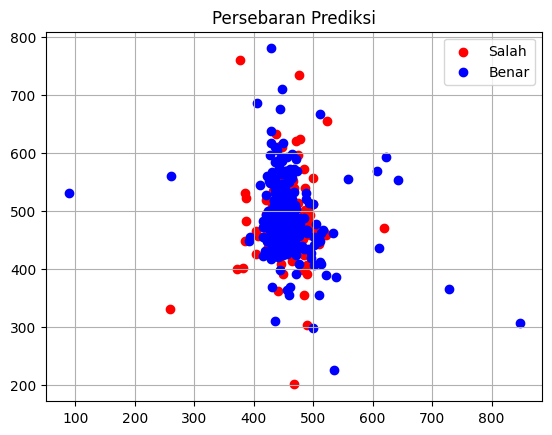

In [730]:
incorrect = y_test != y_pred_test

plt.scatter(X_test.values[incorrect, 0], X_test.values[incorrect, 1], color='red', label='Salah')
plt.scatter(X_test.values[~incorrect, 0], X_test.values[~incorrect, 1], color='blue', label='Benar')
plt.title('Persebaran Prediksi')
plt.legend()
plt.grid()
plt.show()

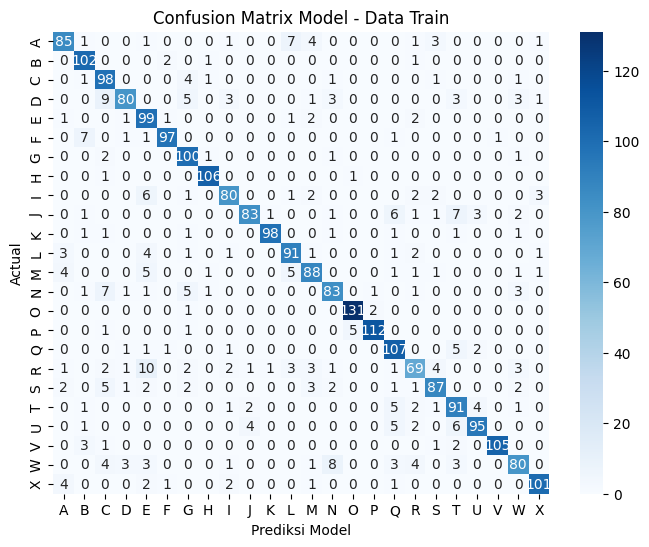

In [731]:
visualize_matrix(y_train, y_pred_train, 'Train')

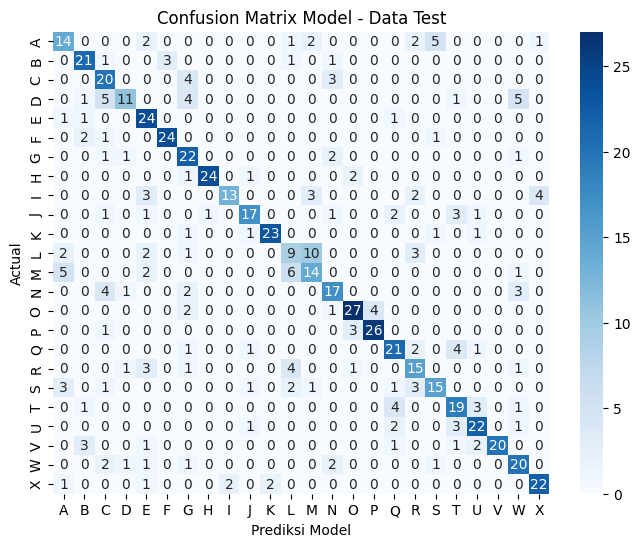

In [732]:
visualize_matrix(y_test, y_pred_test, 'Test')